# EDA

## IMPORTAR PAQUETES

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## IMPORTAR LOS DATOS

Cargar los datos.

In [17]:
cat = pd.read_pickle('../02_datos/03_Entrenamiento/cat_calidad.pkl')
num = pd.read_pickle('../02_datos/03_Entrenamiento/num_calidad.pkl')

## EDA CATEGÓRICAS

### Análisis estadístico

In [18]:
variables = ['antigüedad_empleo', 'ingresos_verificados', 'rating', 'vivienda',
       'finalidad', 'num_cuotas', 'estado']

In [19]:
def frecuencias_cat(df_cat):
    resultado = df_cat[variables].apply(lambda x: x.value_counts(normalize = True)).T.stack()\
                .to_frame().reset_index()\
                .rename(columns={'level_0':'Variable','level_1':'Valor',0: "Frecuencia"})\
                .sort_values(by = ['Variable','Frecuencia'])
    return(resultado)

In [20]:
frecuencias_cat(cat)

,Variable,Valor,Frecuencia
9,antigüedad_empleo,9 years,0.035
8,antigüedad_empleo,8 years,0.041
7,antigüedad_empleo,7 years,0.042
6,antigüedad_empleo,6 years,0.045
4,antigüedad_empleo,4 years,0.060
5,antigüedad_empleo,5 years,0.063
11,antigüedad_empleo,desconocido,0.065
0,antigüedad_empleo,1 year,0.066
3,antigüedad_empleo,3 years,0.081
10,antigüedad_empleo,< 1 year,0.083


### Análisis gráfico

In [21]:
def graficos_eda_categoricos(cat):
    
    #Calculamos el número de filas que necesitamos
    from math import ceil
    filas = ceil(cat.shape[1] / 2)

    #Definimos el gráfico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat 

    #Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(cat):
        cat[variable].value_counts().plot.barh(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)

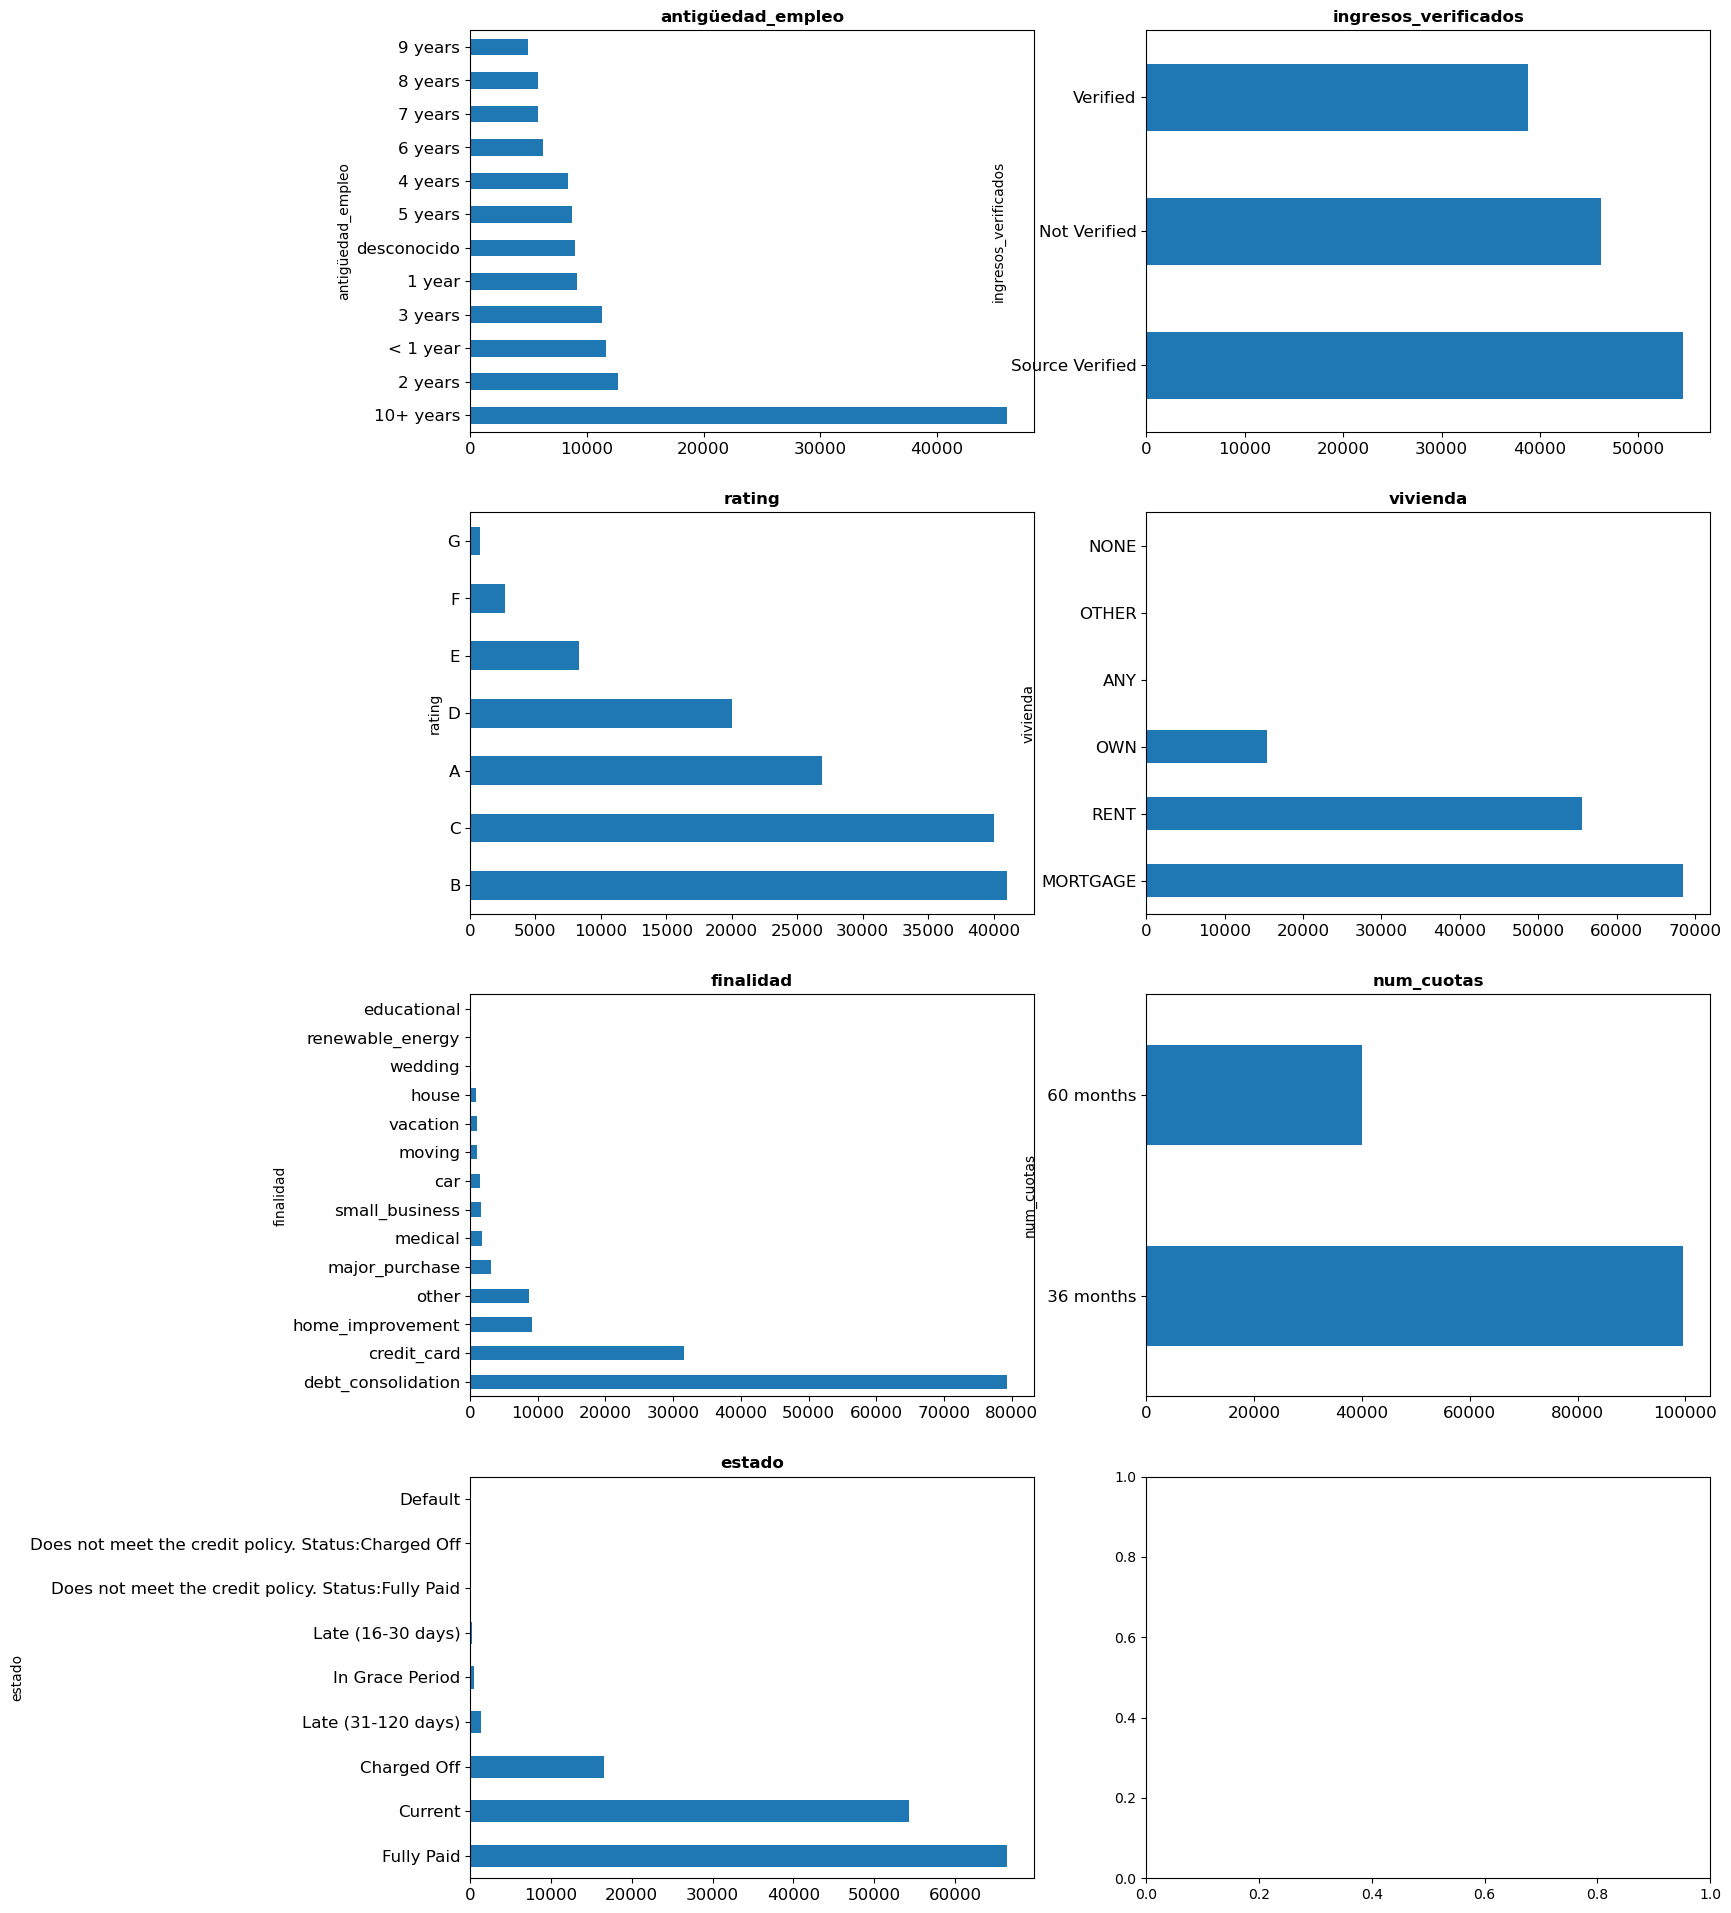

In [22]:
graficos_eda_categoricos(cat[variables])

Conclusiones:

En transformación:

* En vivienda juntar ANY, NONE y OTHER a la categoria mayoritaria
* En finalidad juntar renewable_energy, educational y wedding en 'otros'
* Crear la target a partir de estado

## EDA NUMÉRICAS

### Análisis estadístico

In [23]:
def estadisticos_cont(num):
    #Calculamos describe
    estadisticos = num.describe().T
    #Añadimos la mediana
    estadisticos['median'] = num.median()
    #Reordenamos para que la mediana esté al lado de la media
    estadisticos = estadisticos.iloc[:,[0,1,8,2,3,4,5,6,7]]
    #Lo devolvemos
    return(estadisticos)

In [24]:
estadisticos_cont(num)

,count,mean,median,std,min,25%,50%,75%,max
id_cliente,139597.000,80287454.921,84303231.000,44946369.957,65640.000,44925876.000,84303231.000,122316480.000,145640422.000
ingresos,139597.000,76094.185,65000.000,45458.664,0.000,46000.000,65000.000,92500.000,400000.000
dti,139597.000,18.822,17.780,14.584,-1.000,11.920,17.780,24.460,999.000
num_hipotecas,139597.000,1.510,1.000,1.883,0.000,0.000,1.000,2.000,32.000
num_lineas_credito,139597.000,11.605,11.000,5.634,0.000,8.000,11.000,14.000,91.000
porc_tarjetas_75p,139597.000,41.174,33.300,36.462,0.000,0.000,33.300,66.700,100.000
porc_uso_revolving,139597.000,50.385,50.400,24.741,0.000,31.700,50.400,69.400,366.600
num_cancelaciones_12meses,139597.000,0.009,0.000,0.104,0.000,0.000,0.000,0.000,7.000
num_derogatorios,139597.000,0.197,0.000,0.569,0.000,0.000,0.000,0.000,46.000
num_meses_desde_ult_retraso,139597.000,16.823,0.000,23.030,0.000,0.000,0.000,31.000,195.000


### Análisis gráfico

In [25]:
def graficos_eda_continuas(num):
    
    #Calculamos el número de fila que necesitamos
    from math import ceil
    filas = ceil(num.shape[1] / 2)

    #Definimos el gráfico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat 

    #Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(num):
        num[variable].plot.density(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)

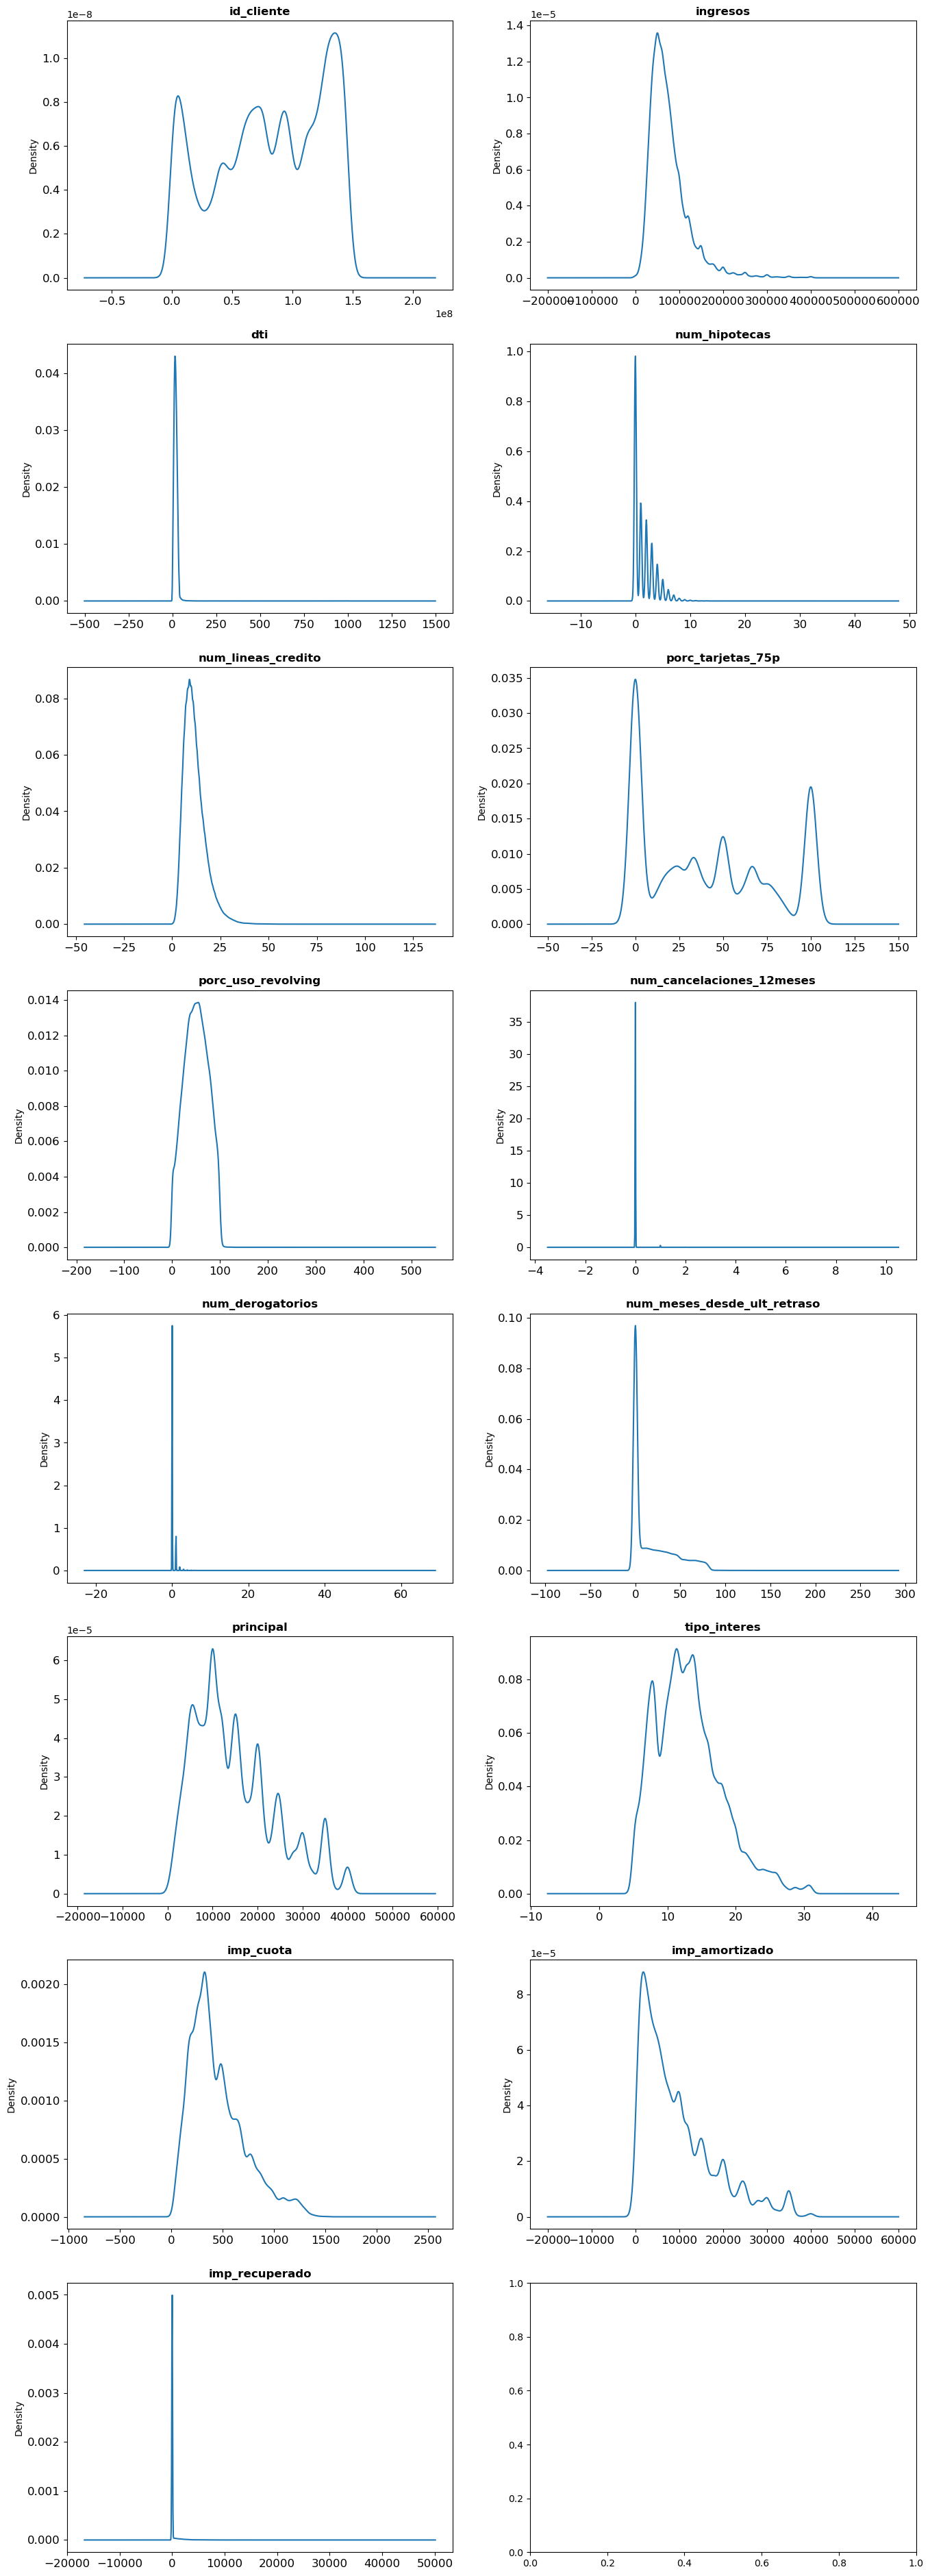

In [26]:
graficos_eda_continuas(num)

Vamos a analizar el detalle de imp_amortizado e imp_recuperado, ya que son relevantes para la target del modelo LGD.

In [27]:
ratios = num[['principal','imp_amortizado','imp_recuperado']].copy()

In [28]:
ratios['r_amortizado_principal'] = ratios.imp_amortizado / ratios.principal
ratios['r_recuperado_principal'] = ratios.imp_recuperado / ratios.principal

In [29]:
ratios.describe().T

,count,mean,std,min,25%,50%,75%,max
principal,139597.000,14995.425,9153.110,1000.000,8000.000,12800.000,20000.000,40000.000
imp_amortizado,139597.000,9485.798,8294.905,0.000,3000.000,7000.000,13839.960,40000.000
imp_recuperado,139597.000,144.919,768.496,0.000,0.000,0.000,0.000,33407.160
r_amortizado_principal,139597.000,0.662,0.369,0.000,0.275,0.871,1.000,1.000
r_recuperado_principal,139597.000,0.009,0.042,0.000,0.000,0.000,0.000,1.221


## Conclusiones:

- DTI: valores negativos o superiores a 100 no tienen sentido de negocio y deben ser tratados como atípicos.
- num_hipotecas: valores superiores a 7 son extremadamente raros y probablemente errores.
- porc_uso_revolving: valores superiores a 100% no son posibles y deben considerarse errores.
- Para estas variables, se recomienda winsorizar a los límites indicados o eliminar los registros si el número de atípicos es muy bajo.
- En transformación convertir num_derogatorios a binaria
- Revisar en profundidad la relación entre estado e imp_recuperado

In [30]:
# Winsorización de variables numéricas con valores atípicos en el DataFrame num
import numpy as np

num['DTI'] = np.clip(num['dti'], 0, 100)
num['num_hipotecas'] = np.clip(num['num_hipotecas'], 0, 7)
num['porc_uso_revolving'] = np.clip(num['porc_uso_revolving'], 0, 100)


In [31]:
temp = cat[['estado']].merge(num[['imp_recuperado']], left_index=True, right_index=True)
temp.groupby('estado').imp_recuperado.mean()

estado
Charged Off                                           1218.584
Current                                                  0.000
Default                                                  0.000
Does not meet the credit policy. Status:Charged Off    393.696
Does not meet the credit policy. Status:Fully Paid       0.000
Fully Paid                                               0.000
In Grace Period                                          0.000
Late (16-30 days)                                        0.000
Late (31-120 days)                                       0.000
Name: imp_recuperado, dtype: float64

Efectivamente sólo hay importe recuperado en el estado Charged Off.

## GUARDAR DATASETS TRAS EDA

In [32]:
#Guardar los archivos
cat.to_pickle('../02_datos/03_Entrenamiento/cat_eda.pkl')
num.to_pickle('../02_datos/03_Entrenamiento/num_eda.pkl')